# 📡 ETF Predictor — Fase 4: Generador de Señales
**Notebook:** `ETF_Predictor_Part4.ipynb`  
Carga los modelos entrenados en la Fase 3, descarga los datos más recientes,
y genera automáticamente una señal de trading con Precio de Entrada, Stop-Loss y Take-Profit.

In [1]:
# ── CELDA 0 — Instalación de dependencias ────────────────────────────────────
!pip install xgboost==2.0.3 yfinance==0.2.38 --quiet
!pip install ta pandas numpy matplotlib --quiet

import xgboost, yfinance, pandas, numpy
print(f'✅ XGBoost:  {xgboost.__version__}')
print(f'✅ yfinance: {yfinance.__version__}')
print(f'✅ Todo listo')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ XGBoost:  2.0.3
✅ yfinance: 0.2.38
✅ Todo listo


In [2]:
# ── CELDA 1 — Imports y configuración central ────────────────────────────────
import os, json, shutil, warnings, logging
from datetime import datetime
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s — %(levelname)s — %(message)s'
)
logger = logging.getLogger(__name__)

CONFIG = {
    'DATA_DIR':     '/content/data',
    'MODEL_DIR':    '/content/data/models',
    'SIGNALS_FILE': '/content/data/signals_output.csv',
    'DRIVE_DIR':    '/content/drive/MyDrive/ETF_Predictor/data',
    'TICKER':       'EXS1.DE',
    'FREQUENCY':    '1wk',

    # Gestión del riesgo
    'STOP_LOSS_ATR_MULT':   1.5,   # Stop-Loss  = precio - (ATR x 1.5)
    'TAKE_PROFIT_ATR_MULT': 2.5,   # Take-Profit = precio + (ATR x 2.5)
    'MIN_CONFIDENCE':       0.55,  # Probabilidad mínima para emitir señal
    'RISK_PER_TRADE':       0.02,  # Máximo 2% del capital por operación
}

os.makedirs(CONFIG['MODEL_DIR'], exist_ok=True)
print('✅ Configuración cargada')

✅ Configuración cargada


In [3]:
# ── CELDA 2 — Restaurar archivos desde Google Drive ──────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

os.makedirs('/content/data/models', exist_ok=True)

DRIVE_DIR    = CONFIG['DRIVE_DIR']
DRIVE_MODELS = os.path.join(DRIVE_DIR, 'models')

# Restaurar CSVs
for filename in ['raw_data.csv', 'sentiment_scores.csv']:
    src  = os.path.join(DRIVE_DIR, filename)
    dest = os.path.join(CONFIG['DATA_DIR'], filename)
    if os.path.exists(src):
        shutil.copy2(src, dest)
        print(f'✅ {filename}')
    else:
        print(f'⚠️  No encontrado: {filename}')

# Restaurar modelos
for filename in ['xgb_classifier.json', 'xgb_regressor.json',
                 'feature_cols.json', 'model_metrics.json']:
    src  = os.path.join(DRIVE_MODELS, filename)
    dest = os.path.join(CONFIG['MODEL_DIR'], filename)
    if os.path.exists(src):
        shutil.copy2(src, dest)
        print(f'✅ {filename}')
    else:
        print(f'⚠️  No encontrado: {filename}')

print('\n✅ Archivos restaurados')

Mounted at /content/drive
✅ raw_data.csv
✅ sentiment_scores.csv
✅ xgb_classifier.json
✅ xgb_regressor.json
✅ feature_cols.json
✅ model_metrics.json

✅ Archivos restaurados


In [4]:
# ── CELDA 2b — Regenerar merged_dataset.csv si no existe en Drive ────────────
def rebuild_merged(data_dir, drive_dir):
    df_raw  = pd.read_csv(f'{data_dir}/raw_data.csv',
                          index_col='date', parse_dates=True)
    df_sent = pd.read_csv(f'{data_dir}/sentiment_scores.csv',
                          index_col='date', parse_dates=True)

    df = df_raw.join(df_sent, how='left', rsuffix='_sent')

    sent_cols = df_sent.columns.tolist()
    df[sent_cols] = df[sent_cols].fillna(method='ffill', limit=2)

    target_cols = [c for c in df.columns if 'target' in c]
    if target_cols:
        df = df.dropna(subset=target_cols[:1])

    merged_path = f'{data_dir}/merged_dataset.csv'
    df.to_csv(merged_path, index=True, float_format='%.6f')

    dest = os.path.join(drive_dir, 'merged_dataset.csv')
    shutil.copy2(merged_path, dest)

    print(f'✅ merged_dataset.csv regenerado: {df.shape}')
    print(f'☁️  Backup en Drive: {dest}')
    return df


merged_path_check = os.path.join(CONFIG['DRIVE_DIR'], 'merged_dataset.csv')
if not os.path.exists(merged_path_check):
    print('ℹ️  merged_dataset.csv no encontrado — regenerando...')
    df_merged = rebuild_merged(CONFIG['DATA_DIR'], CONFIG['DRIVE_DIR'])
else:
    shutil.copy2(merged_path_check,
                 os.path.join(CONFIG['DATA_DIR'], 'merged_dataset.csv'))
    print('✅ merged_dataset.csv restaurado desde Drive')

✅ merged_dataset.csv restaurado desde Drive


In [5]:
# ── CELDA 3 — Cargar modelos entrenados (API nativa XGBoost Booster) ─────────
def load_models(model_dir: str):
    """
    Carga los modelos usando xgb.Booster directamente.
    Evita el error NotFittedError del wrapper sklearn.
    """
    with open(os.path.join(model_dir, 'feature_cols.json'), 'r') as f:
        feature_cols = json.load(f)

    with open(os.path.join(model_dir, 'model_metrics.json'), 'r') as f:
        metrics = json.load(f)

    clf_booster = xgb.Booster()
    clf_booster.load_model(os.path.join(model_dir, 'xgb_classifier.json'))

    reg_booster = xgb.Booster()
    reg_booster.load_model(os.path.join(model_dir, 'xgb_regressor.json'))

    logger.info(f'✅ Modelos cargados | Features: {len(feature_cols)}')
    logger.info(
        f"   Accuracy: {metrics['classifier']['accuracy']*100:.1f}% "
        f"| AUC: {metrics['classifier']['roc_auc']:.3f}"
    )

    return clf_booster, reg_booster, feature_cols, metrics


clf, reg, feature_cols, metrics = load_models(CONFIG['MODEL_DIR'])
print(f'\n✅ Modelos listos para inferencia')
print(f'   Features requeridos: {len(feature_cols)}')


✅ Modelos listos para inferencia
   Features requeridos: 84


In [6]:
# ── CELDA 4 — Preparar fila de inferencia (versión robusta) ──────────────────
import time

def download_with_retry(ticker, period, interval, max_retries=3):
    """Descarga con reintentos y tickers alternativos."""
    for attempt in range(max_retries):
        try:
            df = yf.download(
                ticker,
                period=period,
                interval=interval,
                auto_adjust=True,
                progress=False,
                timeout=30
            )
            if not df.empty:
                return df
            logger.warning(f"Intento {attempt+1}: DataFrame vacío para {ticker}")
        except Exception as e:
            logger.warning(f"Intento {attempt+1} fallido para {ticker}: {e}")
        time.sleep(3)
    return pd.DataFrame()


def prepare_inference_row(config: dict, feature_cols: list):
    from ta.trend import MACD, EMAIndicator, SMAIndicator
    from ta.momentum import RSIIndicator, StochasticOscillator
    from ta.volatility import BollingerBands, AverageTrueRange
    from ta.volume import OnBalanceVolumeIndicator

    # Tickers alternativos por si EXS1.DE falla
    TICKER_FALLBACKS = ['EXS1.DE', '^IBEX', 'SX5E.PA']

    df = pd.DataFrame()
    used_ticker = None

    for ticker in TICKER_FALLBACKS:
        logger.info(f"⬇️  Intentando descargar {ticker}...")
        df = download_with_retry(ticker, period='5y', interval=config['FREQUENCY'])
        if not df.empty:
            used_ticker = ticker
            logger.info(f"✅ Datos obtenidos de {ticker}: {len(df)} filas")
            break

    # Último fallback: usar la última fila de raw_data.csv
    if df.empty:
        logger.warning("⚠️  yfinance no disponible. Usando última fila de raw_data.csv")
        df_raw = pd.read_csv(
            f"{config['DATA_DIR']}/raw_data.csv",
            index_col='date', parse_dates=True
        )
        last_row = df_raw.iloc[[-1]].copy()

        # Añadir columnas faltantes
        for col in feature_cols:
            if col not in last_row.columns:
                last_row[col] = np.nan

        last_row = last_row[feature_cols]
        last_row = last_row.replace([np.inf, -np.inf], np.nan)
        last_row = last_row.fillna(last_row.median())

        last_close = float(df_raw['close'].iloc[-1])
        last_atr   = float(df_raw['atr'].iloc[-1]) if 'atr' in df_raw.columns else last_close * 0.015
        last_date  = df_raw.index[-1]

        logger.info(f"✅ Fallback CSV | Fecha: {last_date.date()} | Precio: {last_close:.4f}")
        return last_row, last_close, last_atr, last_date

    # Normalizar columnas
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    df.columns    = [col.lower().replace(' ', '_') for col in df.columns]
    df.index      = pd.to_datetime(df.index)
    df.index.name = 'date'

    # Verificar columnas mínimas necesarias
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Columnas faltantes en datos descargados: {missing}")

    # Necesitamos al menos 250 filas para SMA 200
    if len(df) < 50:
        raise ValueError(f"Datos insuficientes: solo {len(df)} filas")

    c = df['close']
    h = df['high']
    l = df['low']
    v = df['volume']
    o = df['open']

    # Retornos
    df['return_1w']  = c.pct_change(1)
    df['return_2w']  = c.pct_change(2)
    df['return_4w']  = c.pct_change(4)
    df['return_12w'] = c.pct_change(12)
    df['log_return'] = np.log(c / c.shift(1))

    # RSI
    df['rsi'] = RSIIndicator(close=c, window=14).rsi()

    # MACD
    macd = MACD(close=c, window_slow=26, window_fast=12, window_sign=9)
    df['macd']        = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    df['macd_diff']   = macd.macd_diff()

    # Bollinger Bands
    bb = BollingerBands(close=c, window=20, window_dev=2)
    df['bb_upper']  = bb.bollinger_hband()
    df['bb_lower']  = bb.bollinger_lband()
    df['bb_middle'] = bb.bollinger_mavg()
    df['bb_width']  = bb.bollinger_wband()
    df['bb_pct']    = bb.bollinger_pband()

    # ATR — con validación de datos suficientes
    if len(df) >= 14:
        atr_ind = AverageTrueRange(high=h, low=l, close=c, window=14)
        df['atr'] = atr_ind.average_true_range()
    else:
        df['atr'] = c * 0.015  # Estimación por defecto: 1.5% del precio
    df['atr_pct'] = df['atr'] / c

    # Medias móviles — solo las que tengan suficientes datos
    for period in [20, 50, 200]:
        if len(df) >= period:
            sma = SMAIndicator(close=c, window=period)
            df[f'sma_{period}']          = sma.sma_indicator()
            df[f'price_vs_sma_{period}'] = (c - df[f'sma_{period}']) / df[f'sma_{period}']
        else:
            df[f'sma_{period}']          = np.nan
            df[f'price_vs_sma_{period}'] = np.nan

    for period in [9, 21, 55]:
        if len(df) >= period:
            ema = EMAIndicator(close=c, window=period)
            df[f'ema_{period}']          = ema.ema_indicator()
            df[f'price_vs_ema_{period}'] = (c - df[f'ema_{period}']) / df[f'ema_{period}']
        else:
            df[f'ema_{period}']          = np.nan
            df[f'price_vs_ema_{period}'] = np.nan

    # Estocástico
    stoch = StochasticOscillator(high=h, low=l, close=c, window=14, smooth_window=3)
    df['stoch_k'] = stoch.stoch()
    df['stoch_d'] = stoch.stoch_signal()

    # Volumen
    df['obv']          = OnBalanceVolumeIndicator(close=c, volume=v).on_balance_volume()
    df['volume_sma20'] = v.rolling(20).mean()
    df['volume_ratio'] = v / df['volume_sma20']

    # Features de vela
    df['candle_body']  = (c - o).abs() / (h - l + 1e-9)
    df['upper_shadow'] = (h - c.clip(lower=o)) / (h - l + 1e-9)
    df['lower_shadow'] = (c.clip(upper=o) - l) / (h - l + 1e-9)
    df['is_bullish']   = (c > o).astype(int)

    # Features temporales
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['month']        = df.index.month
    df['quarter']      = df.index.quarter
    df['is_january']   = (df.index.month == 1).astype(int)
    df['is_q4']        = (df.index.quarter == 4).astype(int)

    # Lags
    for lag in [1, 2, 3, 4, 8, 13]:
        df[f'close_lag_{lag}w']  = c.shift(lag)
        df[f'return_lag_{lag}w'] = df['return_1w'].shift(lag)
        df[f'rsi_lag_{lag}w']    = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}w'] = v.shift(lag)

    # Activos correlacionados
    correlated = {
        'eur_usd':   'EURUSD=X',
        'dax':       '^GDAXI',
        's&p500':    '^GSPC',
        'oro':       'GC=F',
        'petroleo':  'CL=F',
        'vix':       '^VIX',
        'bondes10y': 'ES10Y=X',
    }
    for name, ticker in correlated.items():
        try:
            tmp = download_with_retry(ticker, period='5y', interval='1wk')
            if tmp.empty:
                raise ValueError('Empty')
            if isinstance(tmp.columns, pd.MultiIndex):
                tmp.columns = tmp.columns.droplevel(1)
            tmp.columns  = [col.lower() for col in tmp.columns]
            close_col    = tmp['close'].reindex(df.index, method='ffill')
            df[f'close_{name}']     = close_col
            df[f'return_{name}_1w'] = close_col.pct_change(1)
            df[f'return_{name}_4w'] = close_col.pct_change(4)
        except Exception as e:
            logger.warning(f'⚠️  {ticker} no disponible: {e}')
            df[f'close_{name}']     = np.nan
            df[f'return_{name}_1w'] = np.nan
            df[f'return_{name}_4w'] = np.nan

    # Última fila
    last_row   = df.iloc[[-1]].copy()
    last_close = float(df['close'].iloc[-1])
    last_atr   = float(df['atr'].iloc[-1]) if not pd.isna(df['atr'].iloc[-1]) else last_close * 0.015
    last_date  = df.index[-1]

    # Alinear con feature_cols del modelo
    for col in feature_cols:
        if col not in last_row.columns:
            last_row[col] = np.nan

    last_row = last_row[feature_cols]
    last_row = last_row.replace([np.inf, -np.inf], np.nan)
    last_row = last_row.fillna(last_row.median())

    logger.info(f'✅ Fila lista | Ticker: {used_ticker} | Fecha: {last_date.date()} | Precio: {last_close:.4f}')
    return last_row, last_close, last_atr, last_date


inference_row, last_close, last_atr, last_date = prepare_inference_row(
    CONFIG, feature_cols
)

print(f'\n📅 Semana actual: {last_date.date()}')
print(f'💰 Último precio: {last_close:.4f}')
print(f'📊 ATR actual:    {last_atr:.4f}')

ERROR:yfinance:Failed to get ticker 'EXS1.DE' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EXS1.DE']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
ERROR:yfinance:Failed to get ticker 'EXS1.DE' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EXS1.DE']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
ERROR:yfinance:Failed to get ticker 'EXS1.DE' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['EXS1.DE']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
ERROR:yfinance:Failed to get ticker '^IBEX' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^IBEX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
ERROR:yfinance:Failed to get ticker '^IBEX' reason: Expecting value: line 1 column 1 (char 0)
ERROR:yfinance:
1 Failed downl


📅 Semana actual: 2026-02-22
💰 Último precio: 209.1500
📊 ATR actual:    5.1993


In [7]:
# ── CELDA 5 — Motor de generación de señales ──────────────────────────────────
def generate_signal(
    clf, reg,
    inference_row: pd.DataFrame,
    last_close: float,
    last_atr: float,
    last_date,
    config: dict,
    capital: float = 10000.0
) -> dict:
    """
    Genera señal de trading completa usando la API nativa xgb.Booster.
    """
    dmatrix = xgb.DMatrix(inference_row)

    # Clasificador: probabilidad de clase alcista (1)
    proba_bull  = float(clf.predict(dmatrix)[0])
    # Regresor: retorno esperado de la próxima semana
    pred_return = float(reg.predict(dmatrix)[0])

    # Dirección y confianza
    confidence = max(proba_bull, 1 - proba_bull)
    direction  = 'BUY' if proba_bull >= 0.5 else 'SELL'

    if confidence < config['MIN_CONFIDENCE']:
        direction = 'HOLD'

    # Niveles de precio basados en ATR
    sl_mult = config['STOP_LOSS_ATR_MULT']
    tp_mult = config['TAKE_PROFIT_ATR_MULT']

    if direction == 'BUY':
        entry_price   = round(last_close, 4)
        stop_loss     = round(last_close - (last_atr * sl_mult), 4)
        take_profit   = round(last_close + (last_atr * tp_mult), 4)
        risk_per_unit = entry_price - stop_loss
    elif direction == 'SELL':
        entry_price   = round(last_close, 4)
        stop_loss     = round(last_close + (last_atr * sl_mult), 4)
        take_profit   = round(last_close - (last_atr * tp_mult), 4)
        risk_per_unit = stop_loss - entry_price
    else:
        entry_price = stop_loss = take_profit = last_close
        risk_per_unit = 0

    # Ratio riesgo/beneficio
    rr_ratio = (
        round(abs(take_profit - entry_price) / risk_per_unit, 2)
        if direction != 'HOLD' and risk_per_unit > 0 else 0
    )

    # Position sizing (riesgo fijo % del capital)
    if direction != 'HOLD' and risk_per_unit > 0:
        max_risk_euros = capital * config['RISK_PER_TRADE']
        position_size  = int(max_risk_euros / risk_per_unit)
        position_value = round(position_size * entry_price, 2)
    else:
        position_size  = 0
        position_value = 0

    signal = {
        'fecha_generacion':      datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'semana_datos':          str(last_date.date()),
        'ticker':                config['TICKER'],
        'direccion':             direction,
        'confianza_pct':         round(confidence * 100, 2),
        'prob_alcista_pct':      round(proba_bull * 100, 2),
        'retorno_esperado_pct':  round(pred_return * 100, 2),
        'precio_actual':         round(last_close, 4),
        'precio_entrada':        entry_price,
        'stop_loss':             stop_loss,
        'take_profit':           take_profit,
        'riesgo_por_unidad':     round(risk_per_unit, 4),
        'ratio_rr':              rr_ratio,
        'capital_base':          capital,
        'posicion_unidades':     position_size,
        'valor_posicion_eur':    position_value,
        'atr_usado':             round(last_atr, 4),
    }

    return signal


signal = generate_signal(
    clf, reg, inference_row,
    last_close, last_atr, last_date,
    CONFIG,
    capital=10000.0  # ← Cambia este valor a tu capital real en euros
)

print('\n' + '='*55)
print('📡 SEÑAL DE TRADING GENERADA')
print('='*55)
print(f"  Fecha:              {signal['fecha_generacion']}")
print(f"  Semana de datos:    {signal['semana_datos']}")
print(f"  Ticker:             {signal['ticker']}")
print('─'*55)
print(f"  🎯 DIRECCIÓN:       {signal['direccion']}")
print(f"  📊 Confianza:       {signal['confianza_pct']}%")
print(f"  📈 Prob. alcista:   {signal['prob_alcista_pct']}%")
print(f"  💹 Retorno esperado:{signal['retorno_esperado_pct']}%")
print('─'*55)
print(f"  💰 Precio actual:   {signal['precio_actual']}")
print(f"  🟢 Precio entrada:  {signal['precio_entrada']}")
print(f"  🔴 Stop-Loss:       {signal['stop_loss']}")
print(f"  🎯 Take-Profit:     {signal['take_profit']}")
print(f"  ⚖️  Ratio R/R:       1 : {signal['ratio_rr']}")
print('─'*55)
print(f"  📦 Posición:        {signal['posicion_unidades']} unidades")
print(f"  💶 Valor posición:  {signal['valor_posicion_eur']} €")
print(f"  ⚠️  Riesgo máximo:   {round(signal['capital_base']*CONFIG['RISK_PER_TRADE'],2)} €")
print('='*55)


📡 SEÑAL DE TRADING GENERADA
  Fecha:              2026-03-01 20:55:55
  Semana de datos:    2026-02-22
  Ticker:             EXS1.DE
───────────────────────────────────────────────────────
  🎯 DIRECCIÓN:       BUY
  📊 Confianza:       73.11%
  📈 Prob. alcista:   73.11%
  💹 Retorno esperado:50.06%
───────────────────────────────────────────────────────
  💰 Precio actual:   209.15
  🟢 Precio entrada:  209.15
  🔴 Stop-Loss:       201.3511
  🎯 Take-Profit:     222.1482
  ⚖️  Ratio R/R:       1 : 1.67
───────────────────────────────────────────────────────
  📦 Posición:        25 unidades
  💶 Valor posición:  5228.75 €
  ⚠️  Riesgo máximo:   200.0 €


In [8]:
# ── CELDA 6 — Guardar historial de señales y backup en Drive ──────────────────
def save_signal(signal: dict, signals_file: str, drive_dir: str):
    df_signal = pd.DataFrame([signal])

    if os.path.exists(signals_file):
        df_existing = pd.read_csv(signals_file)
        df_combined = pd.concat([df_existing, df_signal], ignore_index=True)
        df_combined = df_combined.drop_duplicates(
            subset=['semana_datos', 'ticker'], keep='last'
        )
    else:
        df_combined = df_signal

    df_combined.to_csv(signals_file, index=False)
    logger.info(f'💾 Señal guardada: {signals_file}')
    logger.info(f'   Total señales en historial: {len(df_combined)}')

    dest = os.path.join(drive_dir, 'signals_output.csv')
    shutil.copy2(signals_file, dest)
    logger.info(f'☁️  Backup en Drive: {dest}')


save_signal(signal, CONFIG['SIGNALS_FILE'], CONFIG['DRIVE_DIR'])
print('\n✅ Señal guardada en historial')
print(f"   📄 Local: {CONFIG['SIGNALS_FILE']}")
print(f"   ☁️  Drive: {CONFIG['DRIVE_DIR']}/signals_output.csv")


✅ Señal guardada en historial
   📄 Local: /content/data/signals_output.csv
   ☁️  Drive: /content/drive/MyDrive/ETF_Predictor/data/signals_output.csv


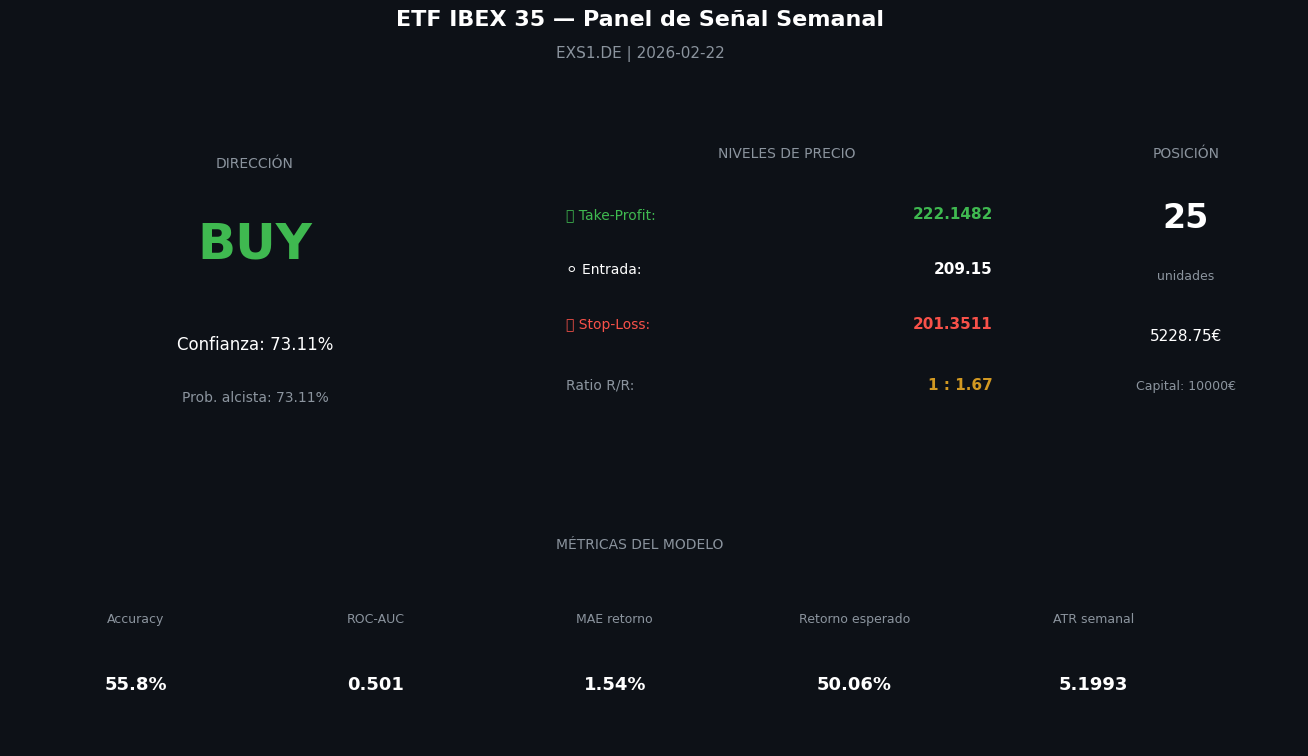

✅ Dashboard guardado en Drive

🎉 PROYECTO ETF PREDICTOR — 100% COMPLETADO
   Para generar la señal de la próxima semana,
   ejecuta este notebook desde la Celda 4 en adelante.


In [9]:
# ── CELDA 7 — Dashboard visual de la señal ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')

fig.text(0.5, 0.95, 'ETF IBEX 35 — Panel de Señal Semanal',
         ha='center', fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.91, f"{signal['ticker']} | {signal['semana_datos']}",
         ha='center', fontsize=11, color='#8b949e')

color_map = {'BUY': '#3fb950', 'SELL': '#f85149', 'HOLD': '#d29922'}
dir_color = color_map.get(signal['direccion'], 'white')

# Panel — Señal
ax1 = fig.add_axes([0.05, 0.45, 0.35, 0.38])
ax1.set_facecolor('#161b22')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')
ax1.text(0.5, 0.85, 'DIRECCIÓN',    ha='center', fontsize=10, color='#8b949e')
ax1.text(0.5, 0.55, signal['direccion'], ha='center', fontsize=36,
         fontweight='bold', color=dir_color)
ax1.text(0.5, 0.25, f"Confianza: {signal['confianza_pct']}%",
         ha='center', fontsize=12, color='white')
ax1.text(0.5, 0.08, f"Prob. alcista: {signal['prob_alcista_pct']}%",
         ha='center', fontsize=10, color='#8b949e')

# Panel — Niveles de precio
ax2 = fig.add_axes([0.43, 0.45, 0.35, 0.38])
ax2.set_facecolor('#161b22')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
ax2.text(0.5, 0.88, 'NIVELES DE PRECIO', ha='center', fontsize=10, color='#8b949e')
ax2.text(0.05, 0.68, '🟢 Take-Profit:', fontsize=10, color='#3fb950')
ax2.text(0.92, 0.68, f"{signal['take_profit']}", fontsize=11,
         fontweight='bold', color='#3fb950', ha='right')
ax2.text(0.05, 0.50, '⚪ Entrada:',     fontsize=10, color='white')
ax2.text(0.92, 0.50, f"{signal['precio_entrada']}", fontsize=11,
         fontweight='bold', color='white', ha='right')
ax2.text(0.05, 0.32, '🔴 Stop-Loss:',  fontsize=10, color='#f85149')
ax2.text(0.92, 0.32, f"{signal['stop_loss']}", fontsize=11,
         fontweight='bold', color='#f85149', ha='right')
ax2.text(0.05, 0.12, 'Ratio R/R:',     fontsize=10, color='#8b949e')
ax2.text(0.92, 0.12, f"1 : {signal['ratio_rr']}", fontsize=11,
         fontweight='bold', color='#d29922', ha='right')

# Panel — Posición
ax3 = fig.add_axes([0.81, 0.45, 0.16, 0.38])
ax3.set_facecolor('#161b22')
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.axis('off')
ax3.text(0.5, 0.88, 'POSICIÓN',    ha='center', fontsize=10, color='#8b949e')
ax3.text(0.5, 0.65, f"{signal['posicion_unidades']}", ha='center',
         fontsize=24, fontweight='bold', color='white')
ax3.text(0.5, 0.48, 'unidades',    ha='center', fontsize=9, color='#8b949e')
ax3.text(0.5, 0.28, f"{signal['valor_posicion_eur']}€",
         ha='center', fontsize=11, color='white')
ax3.text(0.5, 0.12, f"Capital: {int(signal['capital_base'])}€",
         ha='center', fontsize=9, color='#8b949e')

# Panel — Métricas del modelo
ax4 = fig.add_axes([0.05, 0.05, 0.90, 0.28])
ax4.set_facecolor('#161b22')
ax4.set_xlim(0, 1); ax4.set_ylim(0, 1); ax4.axis('off')
ax4.text(0.5, 0.88, 'MÉTRICAS DEL MODELO', ha='center', fontsize=10, color='#8b949e')

model_metrics_display = [
    ('Accuracy',         f"{metrics['classifier']['accuracy']*100:.1f}%"),
    ('ROC-AUC',          f"{metrics['classifier']['roc_auc']:.3f}"),
    ('MAE retorno',      f"{metrics['regressor']['mae']*100:.2f}%"),
    ('Retorno esperado', f"{signal['retorno_esperado_pct']}%"),
    ('ATR semanal',      f"{signal['atr_usado']:.4f}"),
]
for i, (label, value) in enumerate(model_metrics_display):
    x = 0.05 + i * 0.19
    ax4.text(x + 0.05, 0.55, label, ha='center', fontsize=9,  color='#8b949e')
    ax4.text(x + 0.05, 0.25, value, ha='center', fontsize=13,
             fontweight='bold', color='white')

plt.savefig(f"{CONFIG['DATA_DIR']}/signal_dashboard.png",
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

shutil.copy2(f"{CONFIG['DATA_DIR']}/signal_dashboard.png",
             f"{CONFIG['DRIVE_DIR']}/signal_dashboard.png")

print('✅ Dashboard guardado en Drive')
print('\n🎉 PROYECTO ETF PREDICTOR — 100% COMPLETADO')
print('   Para generar la señal de la próxima semana,')
print('   ejecuta este notebook desde la Celda 4 en adelante.')